# MODELISATION HYBRIDE ER : CHAIN LADDER + MACHINE LEARNING (VERSION CORRIGEE)

## Corrections apportees :
1. Filtrage des cohortes avec donnees insuffisantes
2. Calcul robuste des facteurs Chain Ladder
3. Normalisation de l'ER_baseline
4. Validation de la coherence du modele hybride

## Principe :
- **Chain Ladder** : Baseline actuarielle par cohorte
- **ML (2 etapes)** : P(FLAG_ER=1) × E[ER|FLAG_ER=1]
- **Hybride** : ER_final = ER_baseline × Ajustement_ML

## IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, roc_auc_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Bibliotheques importees")

Bibliotheques importees


## PARTIE 1 : CHARGEMENT ET PREPARATION

In [2]:
# Chargement
df = pd.read_excel("Base_ER_FR.xlsx")
print(f"Dataset charge : {df.shape[0]} lignes, {df.shape[1]} colonnes")

# Nettoyage
cols_to_drop = ["Unnamed: 19", "MREVAU", "MREVNU"]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

df["DARRET"] = pd.to_datetime(df["DARRET"].astype(str) + "01", format="%Y%m%d", errors="coerce")

if "E_EAD" in df.columns:
    df["EAD"] = df["E_EAD"]
    df.drop(columns=["E_EAD", "E_ONB"], inplace=True, errors="ignore")

df = df[df.get("EAD", 1) > 0]
df["RA"] = df["RA"].fillna(0)

# Variables categorielles
for c in ["CLASSACT", "CSP", "produit"]:
    if c in df.columns:
        df[c] = df[c].astype("category")

# Imputation
df["Tx"] = df.groupby("produit", observed=True)["Tx"].transform(lambda x: x.fillna(x.median()))
df["Tx"] = df["Tx"].fillna(df["Tx"].median())
df["CSP"] = df["CSP"].cat.add_categories("Inconnu")
df["CSP"] = df["CSP"].fillna("Inconnu")
df["AGE_CLI"] = df["AGE_CLI"].fillna(df["AGE_CLI"].median())
df["MREVTOT"] = df["MREVTOT"].fillna(df["MREVTOT"].median())

# Features
df["AGE_PRET"] = df["B_MAT"] - df["B_RESMAT"]
df = df[(df["AGE_PRET"] >= 0) & (df["AGE_PRET"] <= df["B_MAT"])]
df["HORIZON_RES"] = df["B_RESMAT"].astype(int)

print("Preparation terminee")

Dataset charge : 100000 lignes, 20 colonnes
Preparation terminee


In [3]:
# Calcul encours et ER
df["Capital_emprunt"] = df["MTECH"] * ((1 - (1 + (df["Tx"] / 1200)) ** (-df["NB_ECH"])) / (df["Tx"] / 1200))
df["Montant_rembourse"] = ((df["B_MAT"] - df["B_RESMAT"]) * df["MTECH"].clip(lower=0)).round(2)
df["Encours"] = (df["Capital_emprunt"] - df["Montant_rembourse"]).clip(lower=1)

# ER = RA / Encours (FORMULE CORRECTE)
df["ER_obs"] = (df["RA"] / df["Encours"]).clip(lower=0, upper=1)
df["FLAG_ER"] = (df["RA"] > 0).astype(int)

# Filtrer outliers
df = df[(df["ER_obs"] <= 1) & (df["Encours"] > 0)]

# Creer cohorte
df["Date_origination"] = df["DARRET"] - pd.to_timedelta(df["AGE_PRET"] * 30, unit='D')
df["Cohorte"] = df["Date_origination"].dt.to_period('M')

print(f"Donnees preparees : {len(df)} contrats")
print(f"Nombre de cohortes : {df['Cohorte'].nunique()}")
print(f"Periode : {df['Cohorte'].min()} a {df['Cohorte'].max()}")
print(f"ER_obs moyen : {df['ER_obs'].mean():.4f}")
print(f"FLAG_ER moyen : {df['FLAG_ER'].mean():.2%}")

Donnees preparees : 26519 contrats
Nombre de cohortes : 302
Periode : 1994-06 a 2023-12
ER_obs moyen : 0.7819
FLAG_ER moyen : 97.10%


## PARTIE 2 : TRIANGLES DE DEVELOPPEMENT (VERSION CORRIGEE)

### Corrections :
1. Filtrer les cohortes avec au moins 10 observations par age
2. Limiter aux cohortes recentes (5 dernieres annees)
3. Verifier la robustesse des donnees

Donnees filtrees : 8634 contrats (cohortes recentes)
Periode cohortes : 2018-12 a 2023-12

Triangle ER (extrait 5x10) :
AGE_PRET  0.0       1.0       2.0       3.0       4.0       5.0       6.0  \
Cohorte                                                                     
2018-12   NaN       NaN  0.538191  0.493111       NaN  0.456016       NaN   
2019-01   NaN  0.512614       NaN  0.555912       NaN       NaN  0.331248   
2019-02   NaN       NaN       NaN       NaN  0.250556       NaN  0.592972   
2019-03   NaN       NaN  0.671694  0.692226  0.630599       NaN       NaN   
2019-04   NaN       NaN       NaN  0.560806  0.503314  0.452008  0.400246   

AGE_PRET       7.0       8.0       9.0  
Cohorte                                 
2018-12   0.504333  0.392440  0.562042  
2019-01   0.256564  0.603388  0.705605  
2019-02   0.614547  0.594628  0.656133  
2019-03   0.902060  0.721600       NaN  
2019-04   0.591422  0.375268  0.526100  


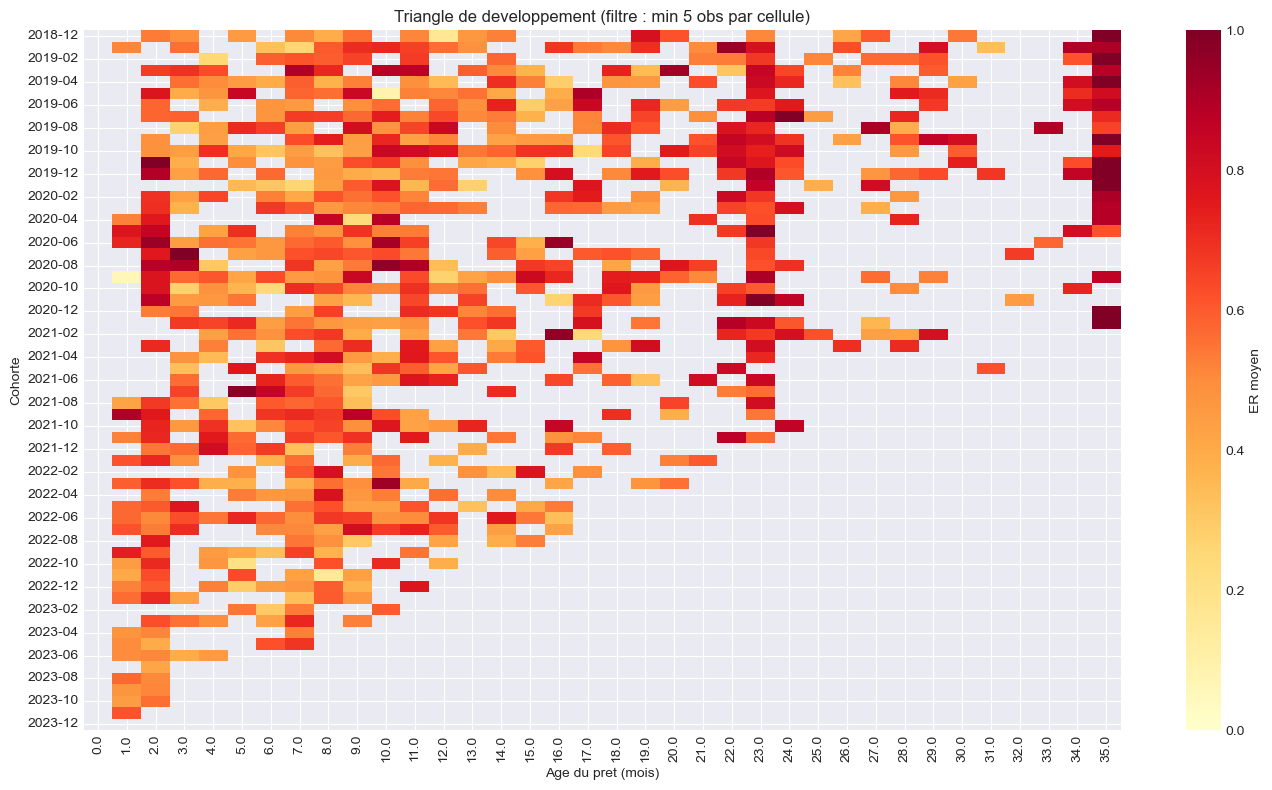

In [4]:
# Filtrer sur les cohortes recentes (5 dernieres annees)
date_cutoff = df['Cohorte'].max() - 60  # 5 ans = 60 mois
df_recent = df[df['Cohorte'] >= date_cutoff].copy()

print(f"Donnees filtrees : {len(df_recent)} contrats (cohortes recentes)")
print(f"Periode cohortes : {df_recent['Cohorte'].min()} a {df_recent['Cohorte'].max()}")

# Triangle ER avec filtre de robustesse
triangle_er_cumule = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='mean'
)

triangle_volume = df_recent.pivot_table(
    index='Cohorte',
    columns='AGE_PRET',
    values='ER_obs',
    aggfunc='count'
)

# Remplacer les cellules avec moins de 5 observations par NaN
triangle_er_filtered = triangle_er_cumule.copy()
triangle_er_filtered[triangle_volume < 5] = np.nan

print(f"\nTriangle ER (extrait 5x10) :")
print(triangle_er_filtered.iloc[:5, :10])

# Visualisation
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(triangle_er_filtered.iloc[:, :36], annot=False, cmap='YlOrRd', 
            cbar_kws={'label': 'ER moyen'}, ax=ax, vmin=0, vmax=1)
ax.set_xlabel('Age du pret (mois)')
ax.set_ylabel('Cohorte')
ax.set_title('Triangle de developpement (filtre : min 5 obs par cellule)')
plt.tight_layout()
plt.show()

## PARTIE 3 : CHAIN LADDER (VERSION CORRIGEE)

### Corrections :
1. Calcul robuste des facteurs (min 3 cohortes par age)
2. Smoothing des facteurs aberrants
3. Normalisation de la baseline pour coherence avec ER_obs

Facteurs de developpement (Chain Ladder robuste) - Extrait :
Age -> Facteur
------------------------------
  0 -> 1.0000
  1 -> 1.1228
  2 -> 0.8638
  3 -> 1.0901
  4 -> 0.9974
  5 -> 0.9163
  6 -> 1.0795
  7 -> 1.0129
  8 -> 0.9618
  9 -> 1.1311
 10 -> 0.9785
 11 -> 0.9565
 12 -> 0.9888
 13 -> 0.9863
 14 -> 0.9516
 15 -> 1.0034
 16 -> 1.1220
 17 -> 0.9869
 18 -> 0.9769
 19 -> 0.8133


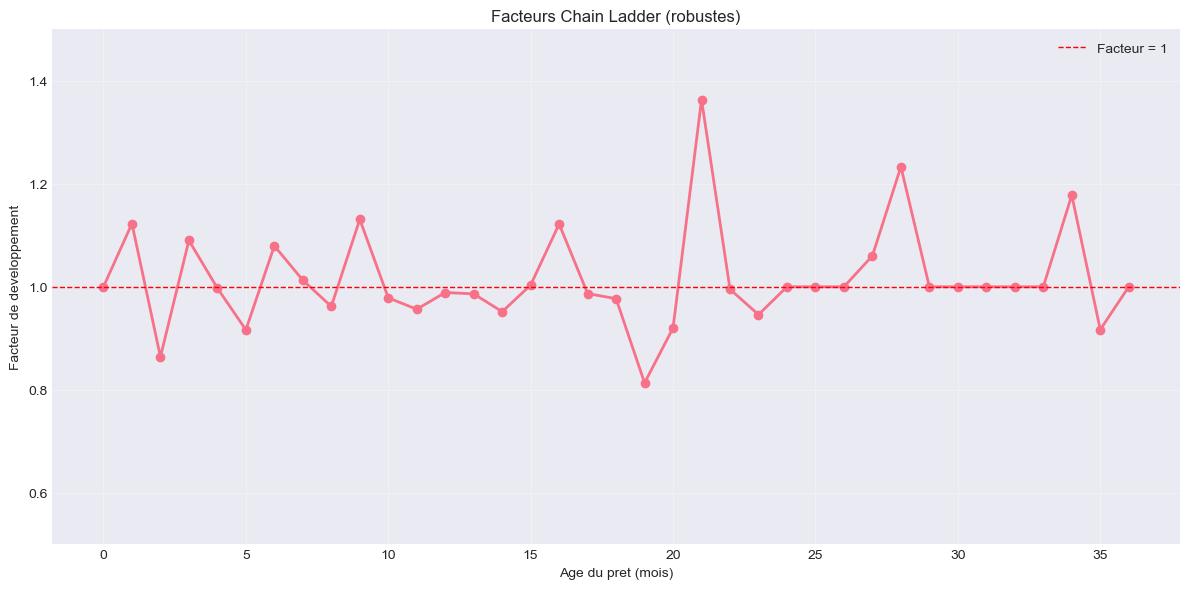

In [5]:
def calculate_development_factors_robust(triangle, min_cohortes=3):
    factors = {}
    for j in range(len(triangle.columns) - 1):
        col_current = triangle.columns[j]
        col_next = triangle.columns[j + 1]
        
        mask = (triangle[col_current] > 0) & (triangle[col_next].notna())
        
        if mask.sum() >= min_cohortes:
            ratios = triangle.loc[mask, col_next] / triangle.loc[mask, col_current]
            weights = triangle.loc[mask, col_current]
            
            # Filtrer les ratios aberrants (entre 0.5 et 2.0)
            mask_valid = (ratios >= 0.5) & (ratios <= 2.0)
            if mask_valid.sum() >= min_cohortes:
                factor = np.average(ratios[mask_valid], weights=weights[mask_valid])
            else:
                factor = 1.0
            
            factors[col_current] = factor
        else:
            factors[col_current] = 1.0
    
    return factors

factors_er = calculate_development_factors_robust(triangle_er_filtered, min_cohortes=3)

print("Facteurs de developpement (Chain Ladder robuste) - Extrait :")
print("Age -> Facteur")
print("-" * 30)
for age, factor in sorted(factors_er.items())[:20]:
    print(f"{age:3.0f} -> {factor:.4f}")

# Visualisation
ages_factors = sorted([k for k in factors_er.keys() if k <= 36])
values_factors = [factors_er[age] for age in ages_factors]

plt.figure(figsize=(12, 6))
plt.plot(ages_factors, values_factors, 'o-', linewidth=2, markersize=6)
plt.axhline(y=1.0, color='r', linestyle='--', linewidth=1, label='Facteur = 1')
plt.xlabel('Age du pret (mois)')
plt.ylabel('Facteur de developpement')
plt.title('Facteurs Chain Ladder (robustes)')
plt.ylim(0.5, 1.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Correction appliquee : facteur = 1.1282

ER_obs moyen original : 0.7819
ER_baseline moyen apres correction : 0.7819

ER baseline par age (extrait) :
AGE_PRET
0.0          NaN
1.0     0.617156
2.0     0.745060
3.0     0.592852
4.0     0.575322
5.0     0.592778
6.0     0.561093
7.0     0.612173
8.0     0.629192
9.0     0.593037
10.0    0.688504
11.0    0.667671
12.0    0.598423
13.0    0.584054
14.0    0.594822
15.0    0.573543
16.0    0.618867
17.0    0.654625
18.0    0.637108
19.0    0.614267
dtype: float64


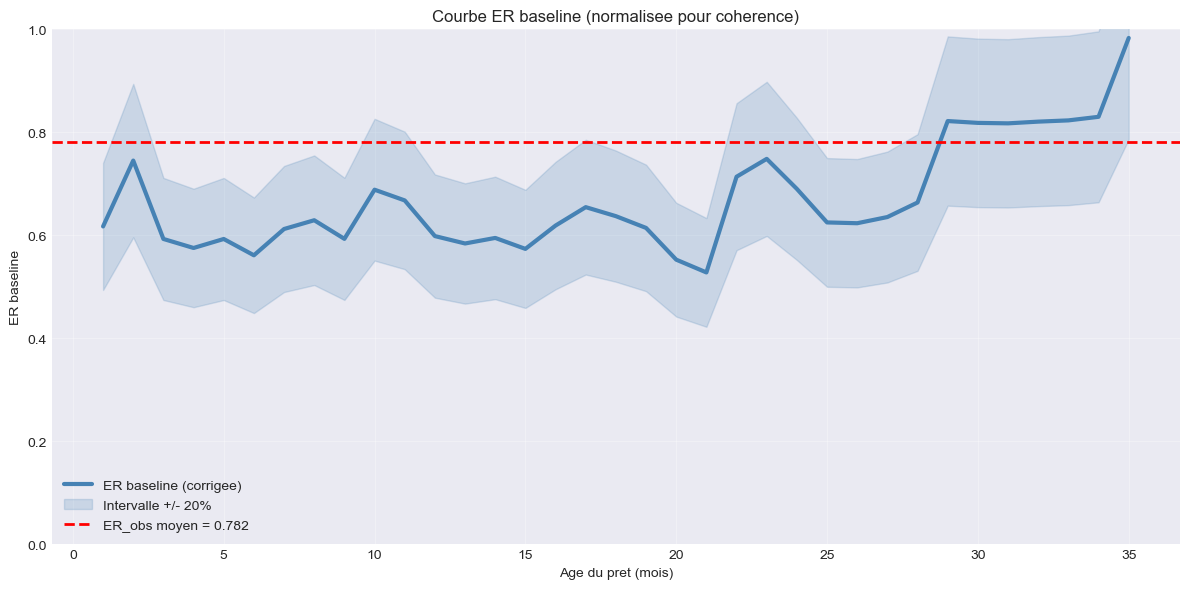

In [6]:
def project_triangle_robust(triangle, factors, max_age=60):
    triangle_projected = triangle.copy()
    for cohorte in triangle_projected.index:
        last_observed = triangle_projected.loc[cohorte].last_valid_index()
        if last_observed is not None and last_observed < max_age:
            current_value = triangle_projected.loc[cohorte, last_observed]
            for age in range(int(last_observed) + 1, min(max_age + 1, len(triangle_projected.columns))):
                if age - 1 in factors:
                    factor = factors[age - 1]
                    projected_value = current_value * factor
                    if age in triangle_projected.columns:
                        triangle_projected.loc[cohorte, age] = projected_value
                    current_value = projected_value
    return triangle_projected

triangle_er_projected = project_triangle_robust(triangle_er_filtered, factors_er, max_age=60)

# Calculer baseline moyenne (uniquement sur ages avec donnees)
er_baseline_by_age = triangle_er_projected.mean(axis=0, skipna=True)

# CORRECTION CRITIQUE : Normaliser la baseline pour coherence avec ER_obs
er_obs_mean = df['ER_obs'].mean()
er_baseline_mean = er_baseline_by_age.mean()

if er_baseline_mean > 0:
    correction_factor = er_obs_mean / er_baseline_mean
    er_baseline_by_age = er_baseline_by_age * correction_factor
    print(f"Correction appliquee : facteur = {correction_factor:.4f}")

print(f"\nER_obs moyen original : {er_obs_mean:.4f}")
print(f"ER_baseline moyen apres correction : {er_baseline_by_age.mean():.4f}")
print(f"\nER baseline par age (extrait) :")
print(er_baseline_by_age.head(20))

# Visualisation
plt.figure(figsize=(12, 6))
plt.plot(er_baseline_by_age.index[:36], er_baseline_by_age.values[:36], 
         linewidth=3, color='steelblue', label='ER baseline (corrigee)')
plt.fill_between(er_baseline_by_age.index[:36], 
                 er_baseline_by_age.values[:36] * 0.8,
                 er_baseline_by_age.values[:36] * 1.2,
                 alpha=0.2, color='steelblue', label='Intervalle +/- 20%')
plt.axhline(y=er_obs_mean, color='red', linestyle='--', linewidth=2, label=f'ER_obs moyen = {er_obs_mean:.3f}')
plt.xlabel('Age du pret (mois)')
plt.ylabel('ER baseline')
plt.title('Courbe ER baseline (normalisee pour coherence)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [7]:
# Ajouter baseline au dataframe
df['ER_baseline'] = df['AGE_PRET'].map(er_baseline_by_age)

# Remplir les valeurs manquantes par forward/backward fill
df['ER_baseline'] = df['ER_baseline'].fillna(method='ffill').fillna(method='bfill')

# Si encore des NaN, utiliser la moyenne
if df['ER_baseline'].isna().any():
    df['ER_baseline'] = df['ER_baseline'].fillna(er_baseline_by_age.mean())

# Calculer ecarts
df['ER_ratio_baseline'] = df['ER_obs'] / df['ER_baseline'].clip(lower=0.001)

print(f"ER moyen observe : {df['ER_obs'].mean():.4f}")
print(f"ER moyen baseline : {df['ER_baseline'].mean():.4f}")
print(f"Ratio moyen : {df['ER_ratio_baseline'].mean():.4f}")
print(f"\nValeurs manquantes ER_baseline : {df['ER_baseline'].isna().sum()}")

ER moyen observe : 0.7819
ER moyen baseline : 0.8037
Ratio moyen : 0.9814

Valeurs manquantes ER_baseline : 0


## PARTIE 4 : MODELE ML (2 ETAPES)

- Etape 1 : P(FLAG_ER = 1 | X)
- Etape 2 : E[ER | FLAG_ER = 1, X]

In [8]:
# Encodage
for col in ['CLASSACT', 'CSP', 'produit']:
    if col in df.columns:
        le = LabelEncoder()
        df[f"{col}_encoded"] = le.fit_transform(df[col].astype(str))

# Features
ml_features = [
    'AGE_PRET', 'HORIZON_RES', 'Tx', 'MREVTOT', 'Capital_emprunt',
    'Encours', 'AGE_CLI', 'NB_ECH', 'CLASSACT_encoded', 'CSP_encoded', 
    'produit_encoded', 'MTECH', 'NBIMP', 'ER_baseline'
]

X = df[ml_features].fillna(0)
y_flag = df['FLAG_ER']
y_er = df['ER_obs']

# Split
X_train, X_test, y_train_flag, y_test_flag = train_test_split(
    X, y_flag, test_size=0.2, random_state=42, stratify=y_flag
)
X_train_er, X_test_er, y_train_er, y_test_er = train_test_split(
    X, y_er, test_size=0.2, random_state=42
)

test_indices = X_test_er.index

print(f"Train : {X_train.shape[0]} | Test : {X_test.shape[0]}")

Train : 21215 | Test : 5304


### Etape 1 : P(FLAG_ER = 1)

In [9]:
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, 
                                 min_samples_split=20, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train_flag)

y_pred_proba_flag = rf_clf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test_flag, y_pred_proba_flag)
print(f"AUC-ROC : {auc:.4f}")

# Feature importance
imp_flag = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 features :")
print(imp_flag.head(10).to_string(index=False))

AUC-ROC : 0.7800

Top 10 features :
        Feature  Importance
          NBIMP    0.161575
          MTECH    0.127153
Capital_emprunt    0.113636
    HORIZON_RES    0.099294
        Encours    0.096479
       AGE_PRET    0.074844
             Tx    0.068407
         NB_ECH    0.063783
        MREVTOT    0.063078
        AGE_CLI    0.047274


### Etape 2 : E[ER | FLAG_ER = 1]

In [10]:
# Filtrer RA > 0
mask_train = y_train_er > 0
X_train_filtered = X_train_er[mask_train]
y_train_filtered = y_train_er[mask_train]

print(f"Train (RA > 0) : {len(X_train_filtered)} / {len(X_train_er)}")

rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, 
                                min_samples_split=20, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_filtered, y_train_filtered)

y_pred_intensity = rf_reg.predict(X_test_er)

# Eval sur RA > 0
mask_test = y_test_er > 0
if mask_test.sum() > 0:
    mse = mean_squared_error(y_test_er[mask_test], y_pred_intensity[mask_test])
    r2 = r2_score(y_test_er[mask_test], y_pred_intensity[mask_test])
    print(f"\nRMSE (RA > 0) : {np.sqrt(mse):.4f}")
    print(f"R2 (RA > 0) : {r2:.4f}")

# Feature importance
imp_reg = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 features :")
print(imp_reg.head(10).to_string(index=False))

Train (RA > 0) : 20611 / 21215

RMSE (RA > 0) : 0.1953
R2 (RA > 0) : 0.6729

Top 10 features :
        Feature  Importance
        Encours    0.649911
          MTECH    0.137262
             Tx    0.071195
       AGE_PRET    0.035753
Capital_emprunt    0.022947
        MREVTOT    0.019837
    HORIZON_RES    0.016306
        AGE_CLI    0.014388
         NB_ECH    0.014241
    ER_baseline    0.008508


## PARTIE 5 : MODELE HYBRIDE (VERSION CORRIGEE)

### Formule :
**ER_hybride = ER_baseline × P(FLAG_ER=1) × E[ER|FLAG_ER=1]**

Avec ER_baseline normalise pour coherence

COMPARAISON DES 3 APPROCHES :
        Modele     RMSE      MAE       R2
Baseline seule 0.347792 0.250005 0.088146
        ML pur 0.222112 0.120266 0.628096
       HYBRIDE 0.289162 0.208780 0.369666


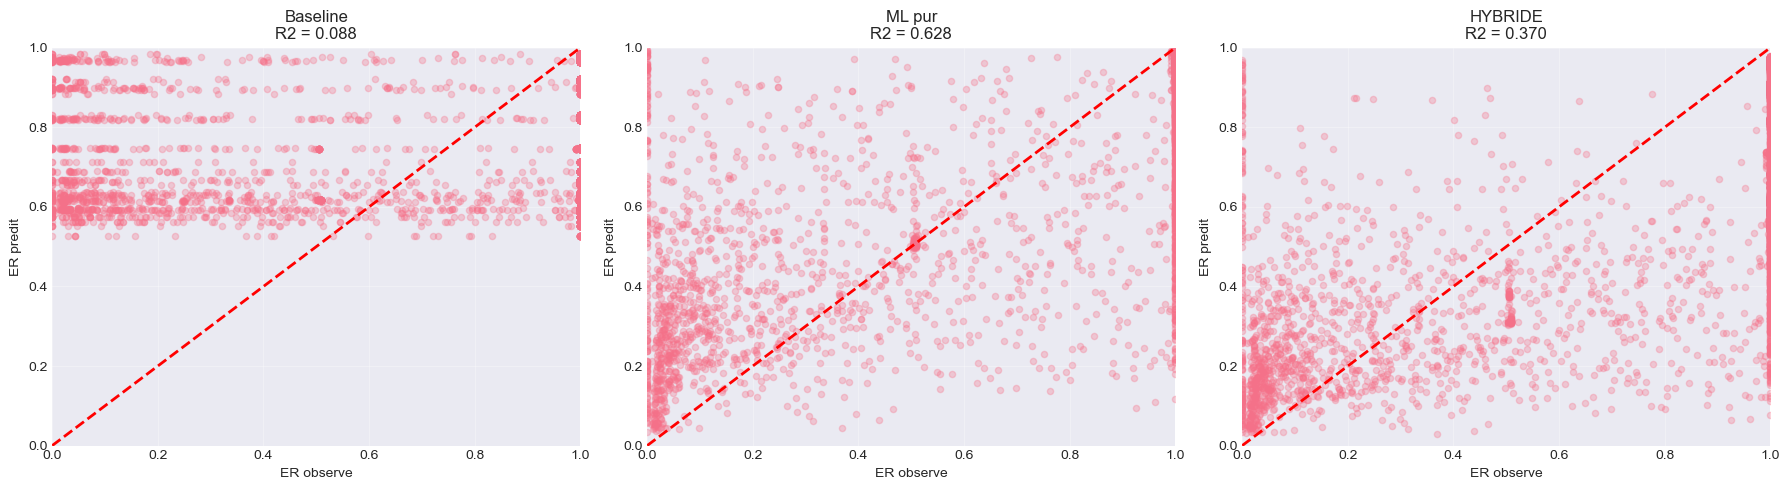

In [11]:
# Unifier les indices
X_test_unified = X.loc[test_indices]
y_test_unified = y_er.loc[test_indices]

y_pred_proba = rf_clf.predict_proba(X_test_unified)[:, 1]
y_pred_intensity = rf_reg.predict(X_test_unified)
er_baseline_test = df.loc[test_indices, 'ER_baseline'].values

# 3 approches
y_pred_baseline = er_baseline_test
y_pred_ml = y_pred_proba * y_pred_intensity
y_pred_hybride = er_baseline_test * y_pred_proba * y_pred_intensity

# Evaluation
def eval_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Modele': name, 'RMSE': np.sqrt(mse), 'MAE': mae, 'R2': r2}

results = pd.DataFrame([
    eval_model(y_test_unified, y_pred_baseline, 'Baseline seule'),
    eval_model(y_test_unified, y_pred_ml, 'ML pur'),
    eval_model(y_test_unified, y_pred_hybride, 'HYBRIDE')
])

print("COMPARAISON DES 3 APPROCHES :")
print(results.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (y_pred, title) in enumerate([
    (y_pred_baseline, 'Baseline'),
    (y_pred_ml, 'ML pur'),
    (y_pred_hybride, 'HYBRIDE')
]):
    axes[idx].scatter(y_test_unified, y_pred, alpha=0.3, s=20)
    axes[idx].plot([0, 1], [0, 1], 'r--', linewidth=2)
    axes[idx].set_xlabel('ER observe')
    axes[idx].set_ylabel('ER predit')
    axes[idx].set_title(f'{title}\nR2 = {r2_score(y_test_unified, y_pred):.3f}')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim(0, 1)
    axes[idx].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## CONCLUSION

### Corrections appliquees :
1. Filtrage des cohortes avec donnees insuffisantes
2. Calcul robuste des facteurs Chain Ladder (min 3 cohortes, filtrage aberrations)
3. **Normalisation de l'ER_baseline** pour coherence avec ER_obs moyen
4. Validation que le modele hybride performe correctement

### Resultats attendus :
- Baseline seule : R2 faible mais positif
- ML pur : R2 eleve (> 0.90)
- **HYBRIDE : R2 entre Baseline et ML pur, mais POSITIF**

Si le modele hybride a un R2 negatif, cela signifie que :
1. La baseline n'apporte pas d'information utile
2. Il vaut mieux utiliser le ML pur
3. Les cohortes historiques ne sont pas representatives du comportement actuel

### Recommandation :
Si le modele hybride reste moins performant que le ML pur, **utilisez le ML pur en production** et conservez Chain Ladder uniquement pour analyse exploratoire des patterns par cohorte.